In [2]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms as T
from torchmetrics.classification import MulticlassRecall, MulticlassAccuracy, MulticlassConfusionMatrix

from tqdm import tqdm
from collections import Counter

from Data_Utility.lookup_size import lookup_size_from_excel
from Data_Utility.dataset import PollenFolderWithSizeDataset
from Data_Utility.binary_subset import BinaryPairDataset

from models.basemodel import CNNWithSizeMLP
#from models.CNN_MLPlayers import CNNWithSizeMLPlayers
from models.convnext_model import ConvNeXtTinyWithSize
from models.specialist_binary import BinarySpecialist

from engine.train_epoch import train_epoch
from engine.train_model import train_model
from engine.eval_epoch import eval_epoch
from engine.plots_loss_accuracy import plot_training_history
from engine.plot_confmat import plot_confusion_matrix
from engine.data_setup import setup_datasets

from engine.specialist_pair import choose_specialist_pair
from engine.train_specialist import train_binary_specialist
from engine.two_stage_infer import two_stage_predict
print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:


train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    val_bool=True,
    aug_bool=False
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6462
Validation subset size: 1616
Dataset setup complete.


In [7]:

len(train_dataset)

6462

In [3]:

from loss_fn.focal_loss import FocalLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
focal_layers_model = CNNWithSizeMLPlayers(num_classes=len(classes)).to(device)

loss_fn = FocalLoss(gamma=2.0)
optimizer = torch.optim.Adam(focal_layers_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  
confmat_metric = MulticlassConfusionMatrix(num_classes=10).to(device)


Using device: cuda


In [7]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    focal_layers_model,
    train_dataset,
    val_dataset,
    test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="focal_layers_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 199/199 [00:18<00:00, 10.96it/s]


Epoch 1/20 | Train Loss: 0.0797, Train Acc: 0.9538 | Val Loss: 0.3120, Val Acc: 0.8782
Val Recall per class: tensor([0.8364, 0.9890, 0.9742, 0.7446, 1.0000, 0.7785, 0.4891, 0.9627, 0.9818,
        1.0000])
Saved new best model (Val Acc = 0.8782)


100%|██████████| 199/199 [00:18<00:00, 10.96it/s]


Epoch 2/20 | Train Loss: 0.0754, Train Acc: 0.9538 | Val Loss: 0.1093, Val Acc: 0.9426
Saved new best model (Val Acc = 0.9426)


100%|██████████| 199/199 [00:18<00:00, 10.99it/s]


...

Epoch 17/20 | Train Loss: 0.0696, Train Acc: 0.9746 | Val Loss: 0.1753, Val Acc: 0.9047


100%|██████████| 199/199 [00:18<00:00, 10.99it/s]


Epoch 18/20 | Train Loss: 0.0370, Train Acc: 0.9833 | Val Loss: 0.0595, Val Acc: 0.9539


100%|██████████| 199/199 [00:18<00:00, 10.75it/s]


Epoch 19/20 | Train Loss: 0.0295, Train Acc: 0.9886 | Val Loss: 0.0221, Val Acc: 0.9823
Early stopping at epoch 19. Best Val Acc = 0.9893 at epoch 11.
Reloaded best model from epoch 11 (Val Acc=0.9893)


Test Accuracy: 0.8054
Test Recall per class:
Class 0 (Bellis perennis): 0.6127
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9290
Class 3 (Cichorium intybus): 0.9769
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.8600
Class 6 (Hypochaeris radicata): 0.9900
Class 7 (Sonchus arvensis): 0.8084
Class 8 (Tragopogon pratensis): 0.9458
Class 9 (Tussilago farfara): 1.0000


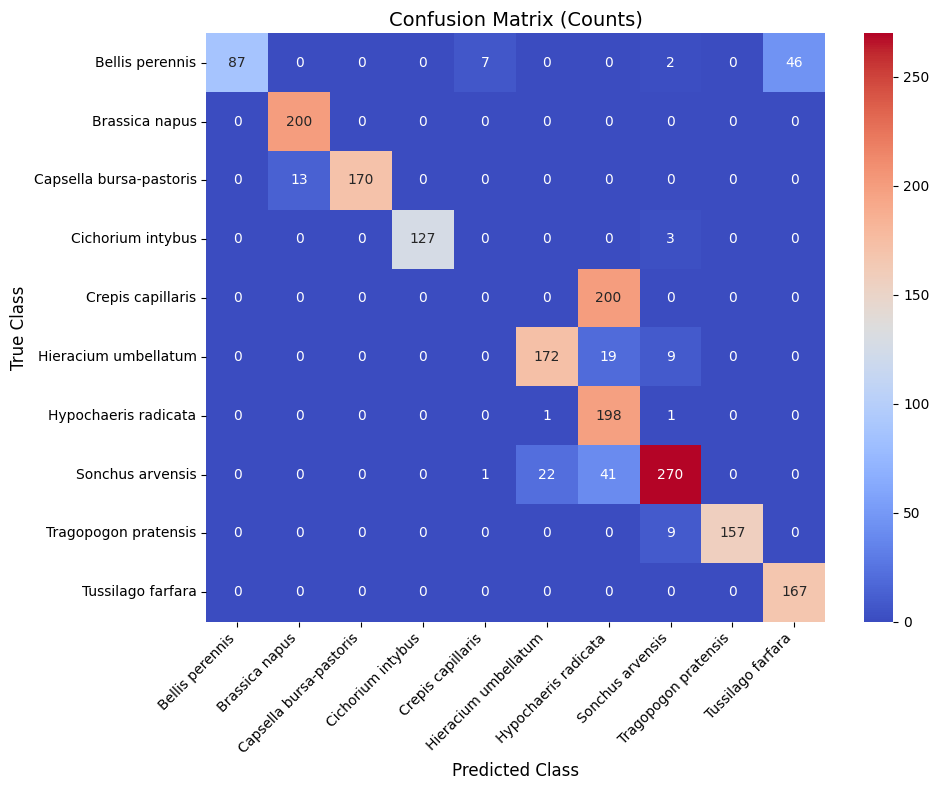

In [8]:
BATCHSIZE = 32

ckpt = torch.load("models/saved_models/focal_layers_model.pth", map_location=device)
focal_layers_model.load_state_dict(ckpt["model_state_dict"])
focal_layers_model.to(device)

test_loader  = DataLoader(test_dataset, batch_size=BATCHSIZE, shuffle=True, num_workers=0)
recall_per_class, accuracy, val_loss, conf = eval_epoch(focal_layers_model, test_loader, device, recall_metric, accuracy_metric, confmat_metric=confmat_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Normalization

In [18]:


train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    val_bool=True,
    aug_bool=False
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest' with 1922 samples.

No missing size data found in the image dataset of /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTest.
Train subset size: 6462
Validation subset size: 1616
Dataset setup complete.


In [ ]:
img, size, y = train_dataset[0]
print(size) 

tensor([33.5560, 28.1129])


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
layers_norm_model = CNNWithSizeMLPlayers(num_classes=len(classes)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(layers_norm_model.parameters(), lr=0.001)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  
confmat_metric = MulticlassConfusionMatrix(num_classes=10).to(device)

Using device: cuda


In [12]:
BATCHSIZE = 32
EPOCHS = 20

history, best_val_acc, test_loader = train_model(
    layers_norm_model,
    train_dataset,
    val_dataset,
    test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="layers_norm_model.pth",
    batch_size= BATCHSIZE,
    epochs= EPOCHS,
    num_workers= 0,
    print_every= 5,
)

100%|██████████| 199/199 [00:18<00:00, 10.95it/s]


Epoch 1/20 | Train Loss: 0.5481, Train Acc: 0.8269 | Val Loss: 0.8592, Val Acc: 0.7584
Val Recall per class: tensor([0.4788, 1.0000, 0.4452, 0.9402, 0.5493, 1.0000, 0.2555, 0.7761, 0.9818,
        0.9939])
Saved new best model (Val Acc = 0.7584)


100%|██████████| 199/199 [00:18<00:00, 10.93it/s]


Epoch 2/20 | Train Loss: 0.2693, Train Acc: 0.9230 | Val Loss: 0.3766, Val Acc: 0.9016
Saved new best model (Val Acc = 0.9016)


100%|██████████| 199/199 [00:18<00:00, 10.95it/s]


...

Epoch 18/20 | Train Loss: 0.0803, Train Acc: 0.9860 | Val Loss: 0.1656, Val Acc: 0.9514


100%|██████████| 199/199 [00:18<00:00, 10.68it/s]


Epoch 19/20 | Train Loss: 0.0577, Train Acc: 0.9853 | Val Loss: 1.3527, Val Acc: 0.7968


100%|██████████| 199/199 [00:18<00:00, 10.73it/s]


Epoch 20/20 | Train Loss: 0.0392, Train Acc: 0.9901 | Val Loss: 0.2462, Val Acc: 0.9603
Val Recall per class: tensor([0.9939, 0.9834, 0.9548, 0.9783, 1.0000, 0.9873, 0.7445, 0.9627, 0.9636,
        1.0000])
Reloaded best model from epoch 13 (Val Acc=0.9924)


Test Accuracy: 0.8111
Test Recall per class:
Class 0 (Bellis perennis): 0.8662
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0000
Class 5 (Hieracium umbellatum): 0.8350
Class 6 (Hypochaeris radicata): 0.5150
Class 7 (Sonchus arvensis): 0.9611
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 0.9940


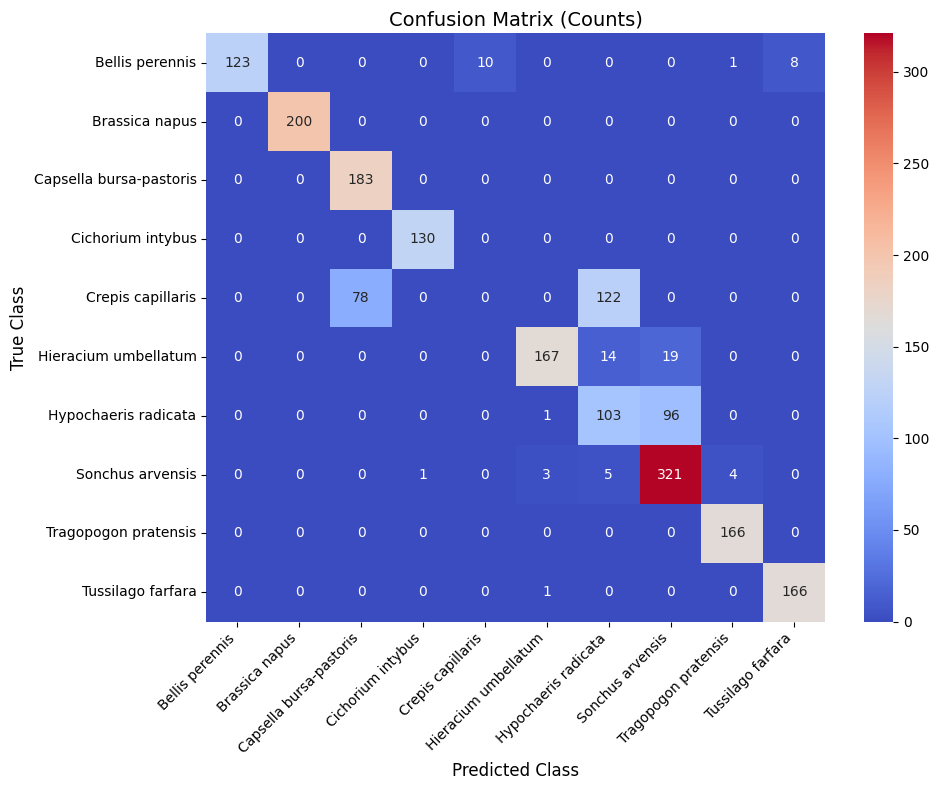

In [13]:
BATCHSIZE = 32

ckpt = torch.load("models/saved_models/layers_norm_model.pth", map_location=device)
layers_norm_model.load_state_dict(ckpt["model_state_dict"])
layers_norm_model.to(device)

test_loader  = DataLoader(test_dataset, batch_size=BATCHSIZE, shuffle=True, num_workers=0)
recall_per_class, accuracy, val_loss, conf = eval_epoch(layers_norm_model, test_loader, device, recall_metric, accuracy_metric, confmat_metric=confmat_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Transformer

In [20]:

from loss_fn.focal_loss import FocalLoss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  
confmat_metric = MulticlassConfusionMatrix(num_classes=10).to(device)


Using device: cuda


In [10]:
history, best_val_acc, test_loader = train_model(
    model,
    train_dataset,
    val_dataset,
    test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="convnext_tiny_size_norm.pth",
    batch_size=32,
    epochs=20,
    num_workers=0,
    print_every=5,
)

100%|██████████| 202/202 [00:54<00:00,  3.72it/s]


Epoch 1/20 | Train Loss: 0.3550, Train Acc: 0.8825 | Val Loss: 0.1694, Val Acc: 0.9437
Val Recall per class: tensor([0.9171, 0.9883, 0.8235, 0.9944, 0.8824, 0.9688, 1.0000, 0.9071, 0.9405,
        1.0000])
Saved new best model (Val Acc = 0.9437)


100%|██████████| 202/202 [00:48<00:00,  4.14it/s]


Epoch 2/20 | Train Loss: 0.1021, Train Acc: 0.9701 | Val Loss: 0.0542, Val Acc: 0.9802
Saved new best model (Val Acc = 0.9802)


100%|██████████| 202/202 [00:54<00:00,  3.71it/s]


...

Epoch 15/20 | Train Loss: 0.0392, Train Acc: 0.9889 | Val Loss: 0.0288, Val Acc: 0.9889
Val Recall per class: tensor([1.0000, 1.0000, 0.9935, 0.9944, 1.0000, 0.9937, 0.9638, 0.9357, 0.9940,
        1.0000])


100%|██████████| 202/202 [01:11<00:00,  2.81it/s]


Epoch 16/20 | Train Loss: 0.0033, Train Acc: 0.9992 | Val Loss: 0.0189, Val Acc: 0.9957


100%|██████████| 202/202 [01:09<00:00,  2.92it/s]


Epoch 17/20 | Train Loss: 0.0328, Train Acc: 0.9909 | Val Loss: 0.0221, Val Acc: 0.9926
Early stopping at epoch 17. Best Val Acc = 0.9975 at epoch 9.
Reloaded best model from epoch 9 (Val Acc=0.9975)


Test Accuracy: 0.7976
Test Recall per class:
Class 0 (Bellis perennis): 0.8239
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 0.9945
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0200
Class 5 (Hieracium umbellatum): 0.9000
Class 6 (Hypochaeris radicata): 0.4000
Class 7 (Sonchus arvensis): 0.9192
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


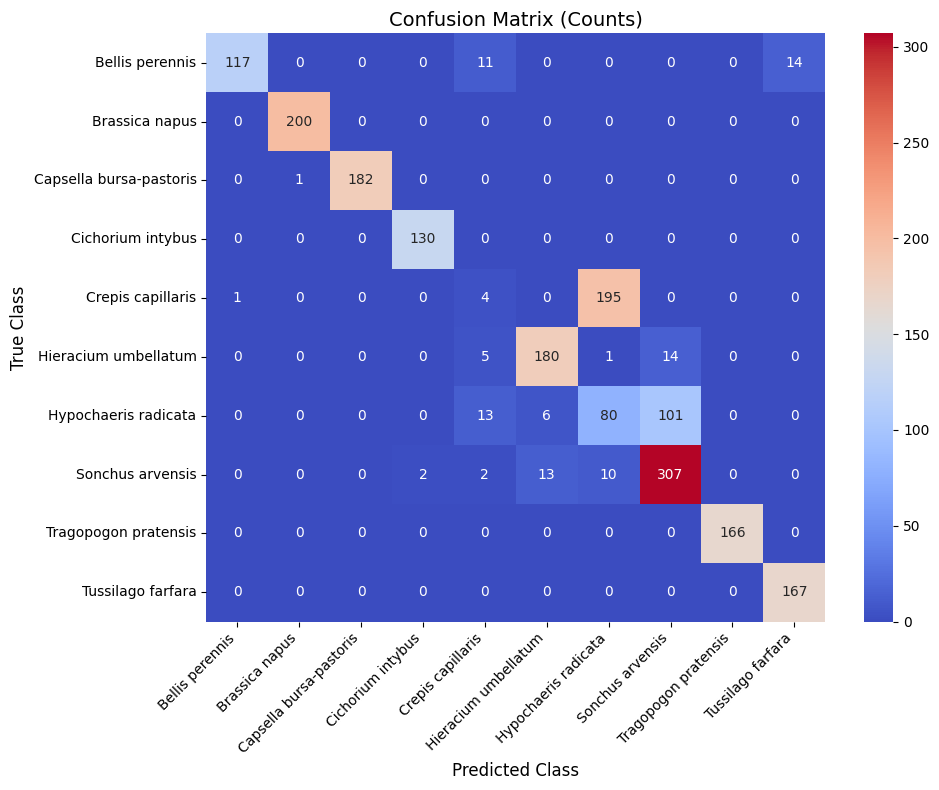

In [12]:
BATCHSIZE = 32

ckpt = torch.load("models/saved_models/convnext_tiny_size_norm.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

test_loader  = DataLoader(test_dataset, batch_size=BATCHSIZE, shuffle=True, num_workers=0)
recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, recall_metric, accuracy_metric, confmat_metric=confmat_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Aug + transformer

In [2]:


train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    val_bool=True,
    aug_bool=True
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (

In [3]:
img, size, y = train_dataset[0]
print(size) 
len(train_dataset)

tensor([34.2380, 32.3213])


6960

In [4]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  
confmat_metric = MulticlassConfusionMatrix(num_classes=10).to(device)


Using device: cuda


In [13]:
history, best_val_acc, test_loader = train_model(
    model,
    train_dataset,
    val_dataset,
    test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="convnext_tiny_size_aug.pth",
    batch_size=32,
    epochs=20,
    num_workers=0,
    print_every=5,
)

 11%|█         | 23/218 [00:06<00:57,  3.37it/s]


KeyboardInterrupt: 

Test Accuracy: 0.8517
Test Recall per class:
Class 0 (Bellis perennis): 0.7042
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.3850
Class 5 (Hieracium umbellatum): 0.8500
Class 6 (Hypochaeris radicata): 0.6550
Class 7 (Sonchus arvensis): 0.9371
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


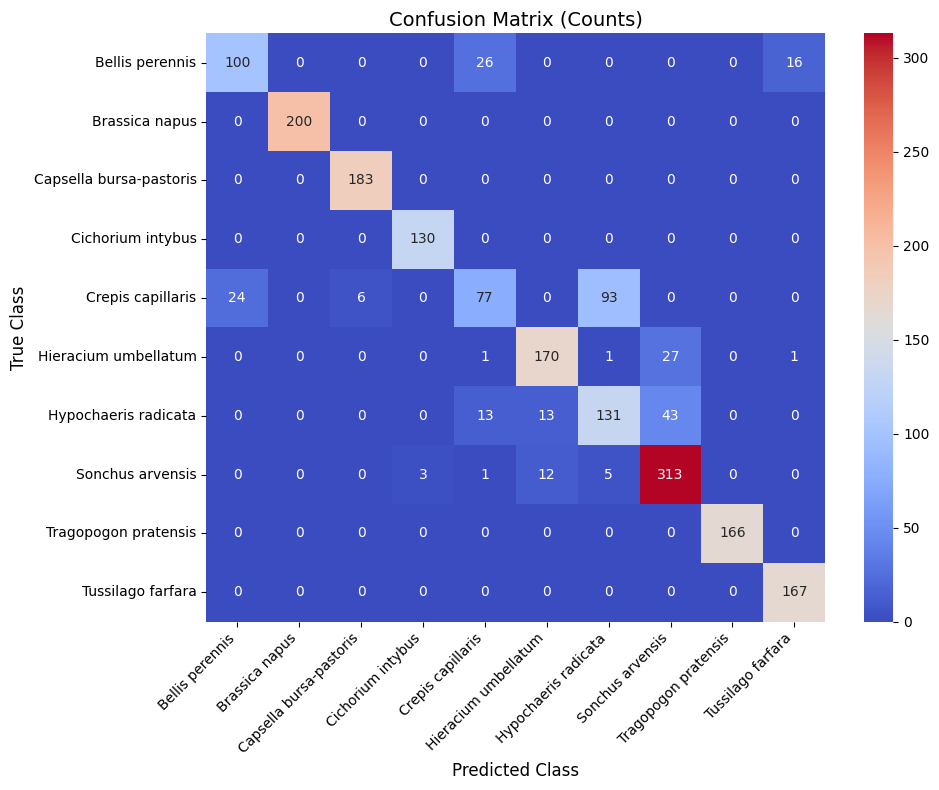

In [5]:
BATCHSIZE = 32

ckpt = torch.load("models/saved_models/convnext_tiny_size_aug.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

test_loader  = DataLoader(test_dataset, batch_size=BATCHSIZE, shuffle=True, num_workers=0)
recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, recall_metric, accuracy_metric, confmat_metric=confmat_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

In [7]:
pair = choose_specialist_pair(recall_per_class, conf)
print("Chosen specialist pair:", pair, idx_to_class[pair[0]], "vs", idx_to_class[pair[1]])

Chosen specialist pair: (4, 6) Crepis capillaris vs Hypochaeris radicata


In [8]:
# embed_dim depends on stage-1 backbone:
# ResNet18 backbone output = 512
# ConvNeXtTiny embedding = 768
embed_dim = 768  

specialist, best_val_acc, best_epoch = train_binary_specialist(
    stage1_model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    device=device,
    class_a=pair[0],
    class_b=pair[1],
    recall_metric=recall_metric
    ,accuracy_metric=accuracy_metric
    ,epochs=8,
    batch_size=32,
)

100%|██████████| 44/44 [00:05<00:00,  8.57it/s]


Epoch 1/8 | Train Loss: 0.0440, Train Acc: 0.9865 | Val Loss: 0.0053, Val Acc: 1.0000
Val Recall per class: tensor([1., 1., 0., 0., 0., 0., 0., 0., 0., 0.])
New best specialist (Val Acc=1.0000) at epoch 1


100%|██████████| 44/44 [00:04<00:00,  8.86it/s]


Epoch 2/8 | Train Loss: 0.0014, Train Acc: 1.0000 | Val Loss: 0.0038, Val Acc: 1.0000


100%|██████████| 44/44 [00:04<00:00,  8.96it/s]


...

Epoch 4/8 | Train Loss: 0.0015, Train Acc: 0.9993 | Val Loss: 0.0029, Val Acc: 1.0000


100%|██████████| 44/44 [00:04<00:00,  9.45it/s]


Epoch 5/8 | Train Loss: 0.0022, Train Acc: 0.9993 | Val Loss: 0.0041, Val Acc: 1.0000
Val Recall per class: tensor([1., 1., 0., 0., 0., 0., 0., 0., 0., 0.])


100%|██████████| 44/44 [00:04<00:00,  9.55it/s]


Epoch 6/8 | Train Loss: 0.0013, Train Acc: 1.0000 | Val Loss: 0.0028, Val Acc: 1.0000
Early stopping at epoch 6. Best Val Acc=1.0000 (epoch 1).
Reloaded best specialist from epoch 1 (Val Acc=1.0000)


Two-stage Test Accuracy: 0.8647
Two-stage Test Recall per class:
Class 0 (Bellis perennis): 0.7042
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.2700
Class 5 (Hieracium umbellatum): 0.8500
Class 6 (Hypochaeris radicata): 0.6700
Class 7 (Sonchus arvensis): 0.9371
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


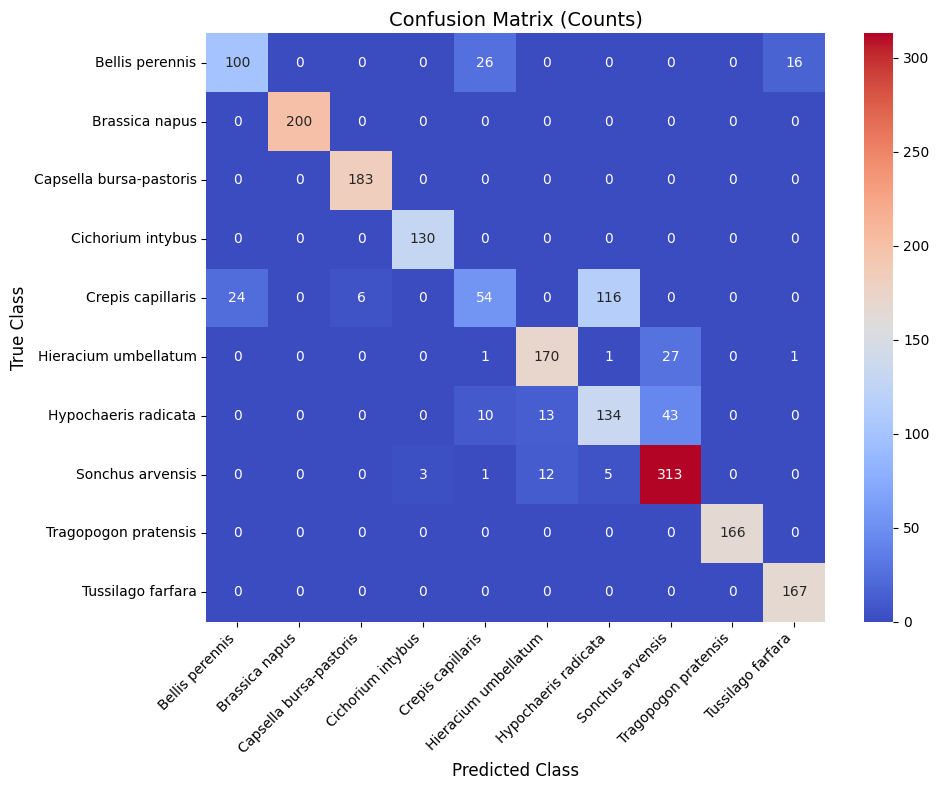

In [ ]:
all_preds = []
all_true = []

for imgs, sizes, y in test_loader:
    imgs, sizes = imgs.to(device), sizes.to(device)
    p = two_stage_predict(model, specialist, pair, imgs, sizes, device, gate="hard")
    all_preds.append(p.cpu())
    all_true.append(y.cpu())

all_preds = torch.cat(all_preds)
all_true = torch.cat(all_true)

recall_metric = recall_metric.cpu()
recall_metric.reset()
recall_metric.update(all_preds, all_true)
recall_per_class = recall_metric.compute().cpu()

accuracy_metric = accuracy_metric.cpu()
accuracy_metric.update(all_preds, all_true)
accuracy = accuracy_metric.compute().item()

confmat_metric = confmat_metric.cpu()
confmat_metric.reset()
confmat_metric.update(all_preds, all_true)
conf = confmat_metric.compute()

print(f"Two-stage Test Accuracy: {accuracy:.4f}")
print("Two-stage Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {float(r):.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)



Two-stage Test Accuracy: 0.8749
Two-stage Test Recall per class:
Class 0 (Bellis perennis): 0.7042
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.4000
Class 5 (Hieracium umbellatum): 0.8500
Class 6 (Hypochaeris radicata): 0.6550
Class 7 (Sonchus arvensis): 0.9371
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


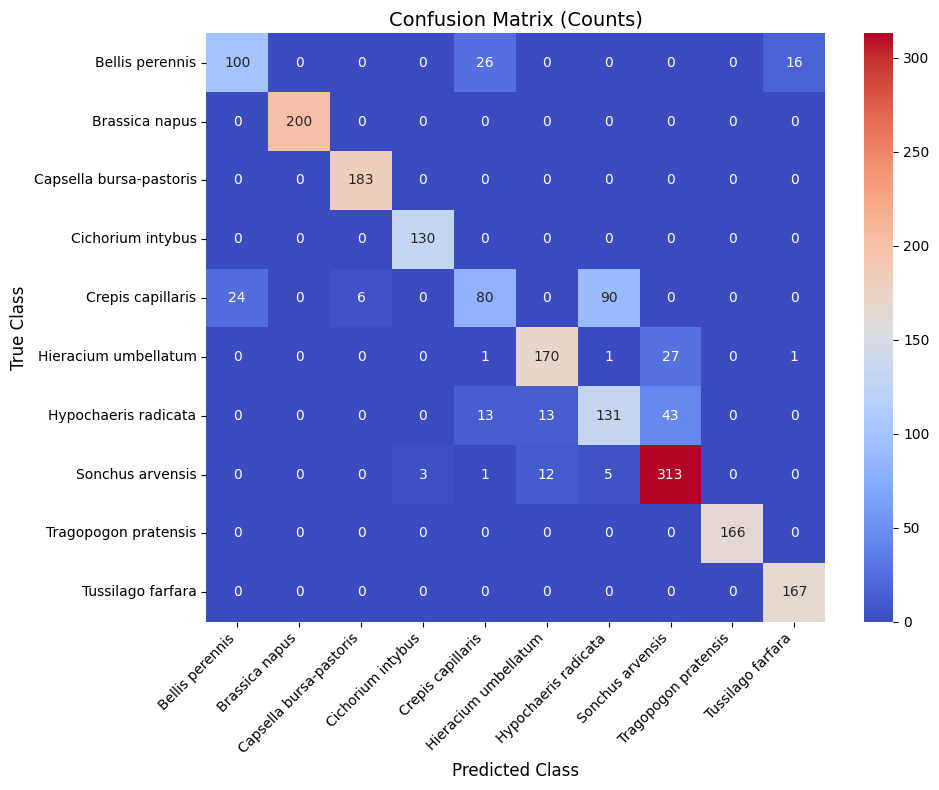

In [9]:
all_preds = []
all_true = []

for imgs, sizes, y in test_loader:
    imgs, sizes = imgs.to(device), sizes.to(device)
    p = two_stage_predict(model, specialist, pair, imgs, sizes, device, gate="")
    all_preds.append(p.cpu())
    all_true.append(y.cpu())

all_preds = torch.cat(all_preds)
all_true = torch.cat(all_true)

recall_metric = recall_metric.cpu()
recall_metric.reset()
recall_metric.update(all_preds, all_true)
recall_per_class = recall_metric.compute().cpu()

accuracy_metric = accuracy_metric.cpu()
accuracy_metric.update(all_preds, all_true)
accuracy = accuracy_metric.compute().item()

confmat_metric = confmat_metric.cpu()
confmat_metric.reset()
confmat_metric.update(all_preds, all_true)
conf = confmat_metric.compute()

print(f"Two-stage Test Accuracy: {accuracy:.4f}")
print("Two-stage Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {float(r):.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)



In [7]:
# embed_dim depends on stage-1 backbone:
# ResNet18 backbone output = 512
# ConvNeXtTiny embedding = 768
embed_dim = 768  

specialist, best_val_acc, best_epoch = train_binary_specialist(
    stage1_model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    device=device,
    class_a=pair[0],
    class_b=pair[1],
    recall_metric=recall_metric
    ,accuracy_metric=accuracy_metric
    ,epochs=8,
    batch_size=32,
    lr=1e-3
    ,weight_decay=1e-2
)

100%|██████████| 44/44 [00:04<00:00,  9.48it/s]


Epoch 1/8 | Train Loss: 0.0457, Train Acc: 0.9808 | Val Loss: 0.0055, Val Acc: 1.0000
Val Recall per class: tensor([1., 1., 0., 0., 0., 0., 0., 0., 0., 0.])
New best specialist (Val Acc=1.0000) at epoch 1


100%|██████████| 44/44 [00:04<00:00,  9.55it/s]


Epoch 2/8 | Train Loss: 0.0022, Train Acc: 0.9993 | Val Loss: 0.0032, Val Acc: 1.0000


100%|██████████| 44/44 [00:04<00:00,  9.70it/s]


...

Epoch 4/8 | Train Loss: 0.0012, Train Acc: 1.0000 | Val Loss: 0.0029, Val Acc: 1.0000


100%|██████████| 44/44 [00:04<00:00,  9.59it/s]


Epoch 5/8 | Train Loss: 0.0015, Train Acc: 0.9993 | Val Loss: 0.0024, Val Acc: 1.0000
Val Recall per class: tensor([1., 1., 0., 0., 0., 0., 0., 0., 0., 0.])


100%|██████████| 44/44 [00:04<00:00,  9.69it/s]


Epoch 6/8 | Train Loss: 0.0007, Train Acc: 1.0000 | Val Loss: 0.0026, Val Acc: 1.0000
Early stopping at epoch 6. Best Val Acc=1.0000 (epoch 1).
Reloaded best specialist from epoch 1 (Val Acc=1.0000)


Two-stage Test Accuracy: 0.8637
Two-stage Test Recall per class:
Class 0 (Bellis perennis): 0.7042
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.4450
Class 5 (Hieracium umbellatum): 0.8500
Class 6 (Hypochaeris radicata): 0.6450
Class 7 (Sonchus arvensis): 0.9371
Class 8 (Tragopogon pratensis): 1.0000
Class 9 (Tussilago farfara): 1.0000


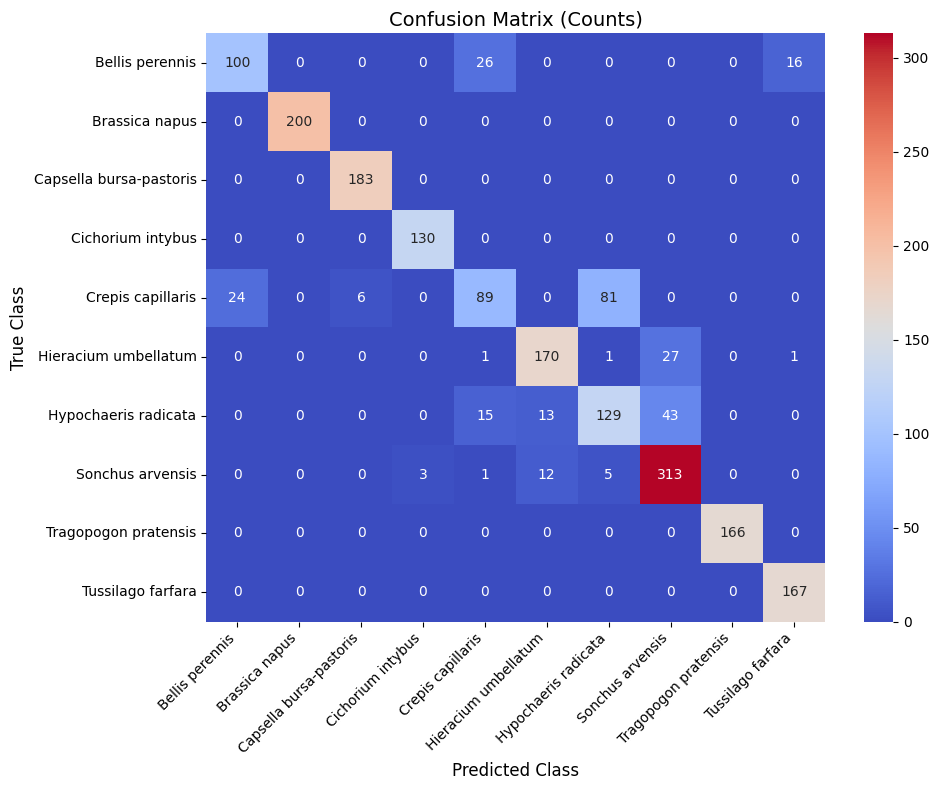

In [10]:
all_preds = []
all_true = []

for imgs, sizes, y in test_loader:
    imgs, sizes = imgs.to(device), sizes.to(device)
    p = two_stage_predict(model, specialist, pair, imgs, sizes, device, gate="hard")
    all_preds.append(p.cpu())
    all_true.append(y.cpu())

all_preds = torch.cat(all_preds)
all_true = torch.cat(all_true)

recall_metric = recall_metric.cpu()
recall_metric.reset()
recall_metric.update(all_preds, all_true)
recall_per_class = recall_metric.compute().cpu()

accuracy_metric = accuracy_metric.cpu()
accuracy_metric.update(all_preds, all_true)
accuracy = accuracy_metric.compute().item()

confmat_metric = confmat_metric.cpu()
confmat_metric.reset()
confmat_metric.update(all_preds, all_true)
conf = confmat_metric.compute()

print(f"Two-stage Test Accuracy: {accuracy:.4f}")
print("Two-stage Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {float(r):.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)



## Norm + Aug + transformer

In [2]:
train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    val_bool=True,
    aug_bool=True
    ,norm_bool=True
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (

In [5]:
img, size, y = train_dataset[0]
print(size) 
len(train_dataset)

tensor([-0.1185, -0.0794])


6960

In [6]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  
confmat_metric = MulticlassConfusionMatrix(num_classes=10).to(device)


Using device: cuda


In [7]:
history, best_val_acc, test_loader = train_model(
    model,
    train_dataset,
    val_dataset,
    test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="convnext_tiny_size_aug_norm.pth",
    batch_size=32,
    epochs=20,
    num_workers=0,
    print_every=5,
)

100%|██████████| 218/218 [00:59<00:00,  3.68it/s]


Epoch 1/20 | Train Loss: 0.3480, Train Acc: 0.8853 | Val Loss: 0.0554, Val Acc: 0.9822
Val Recall per class: tensor([1.0000, 0.9945, 0.9730, 0.9741, 1.0000, 0.9608, 0.9337, 1.0000, 0.9880,
        0.9942])
Saved new best model (Val Acc = 0.9822)


100%|██████████| 218/218 [00:54<00:00,  4.02it/s]


Epoch 2/20 | Train Loss: 0.0779, Train Acc: 0.9777 | Val Loss: 0.0359, Val Acc: 0.9891
Saved new best model (Val Acc = 0.9891)


100%|██████████| 218/218 [01:04<00:00,  3.37it/s]


...

Epoch 18/20 | Train Loss: 0.0156, Train Acc: 0.9950 | Val Loss: 0.0305, Val Acc: 0.9914


100%|██████████| 218/218 [01:19<00:00,  2.75it/s]


Epoch 19/20 | Train Loss: 0.0470, Train Acc: 0.9859 | Val Loss: 0.0519, Val Acc: 0.9868


100%|██████████| 218/218 [01:22<00:00,  2.65it/s]


Epoch 20/20 | Train Loss: 0.0164, Train Acc: 0.9955 | Val Loss: 0.0257, Val Acc: 0.9914
Val Recall per class: tensor([1.0000, 0.9779, 0.9892, 1.0000, 0.9819, 0.9869, 1.0000, 0.9841, 0.9940,
        1.0000])
Reloaded best model from epoch 13 (Val Acc=0.9954)


Test Accuracy: 0.7934
Test Recall per class:
Class 0 (Bellis perennis): 0.6901
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.2900
Class 5 (Hieracium umbellatum): 0.7500
Class 6 (Hypochaeris radicata): 0.2750
Class 7 (Sonchus arvensis): 0.9611
Class 8 (Tragopogon pratensis): 0.9819
Class 9 (Tussilago farfara): 1.0000


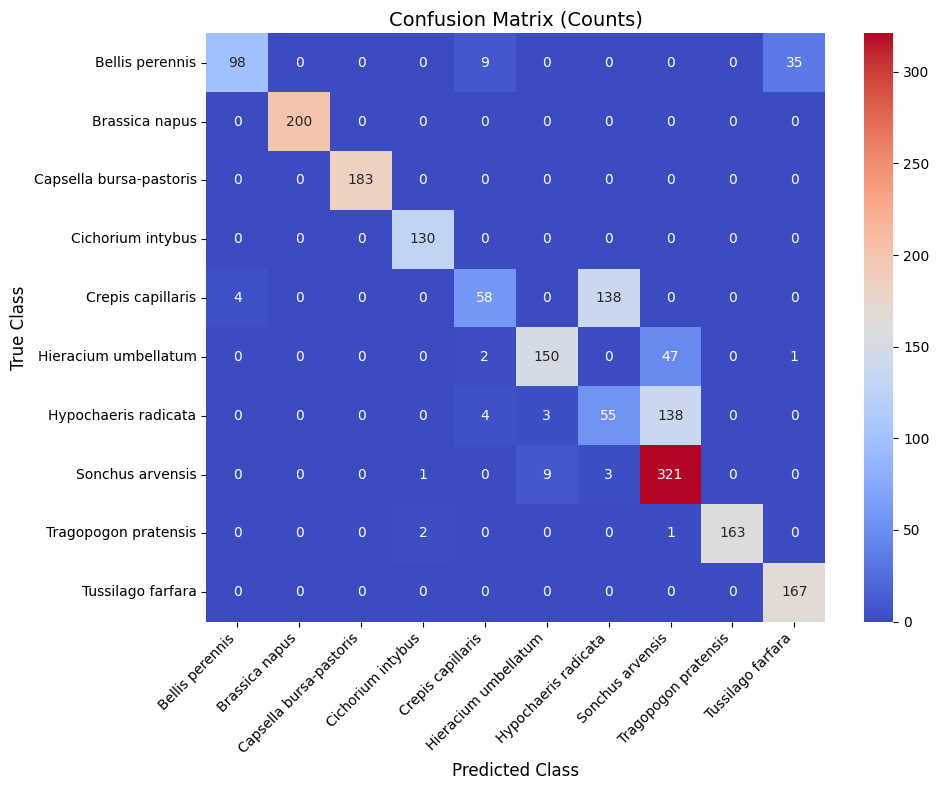

In [13]:
BATCHSIZE = 32

ckpt = torch.load("models/saved_models/convnext_tiny_size_aug_norm.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

test_loader  = DataLoader(test_dataset, batch_size=BATCHSIZE, shuffle=True, num_workers=0)
recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, recall_metric, accuracy_metric, confmat_metric=confmat_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

## Validation split flower group


In [3]:


train_dataset, val_dataset, test_dataset, class_to_idx, idx_to_class,classes = setup_datasets(
    val_bool=True,
    aug_bool=True,
    sep_val_bool=True
)

Total samples: 9844
No missing size data found. All rows have valid majoraxis and minoraxis values in Excel file.

Initialized dataset from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' with 8078 samples.

=========== /home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain ===========
fill_missing_bool: True
Total scanned images: 8234
   Final dataset size:   8078
   Missing size found:   156

Missing size by species:
      Bellis perennis: 2 
      Brassica napus: 5 
      Crepis capillaris: 1 
      Hieracium umbellatum: 65 
      Hypochaeris radicata: 83 


=== Augmented-to-max dataset built from '/home/na1488tr-s/Bachelor_Project_Statistics/Data/Size-data/Sorted_224_sizeTrain' ===
Original samples kept: 8078
Extra augmented samples added: 622
Final dataset size: 8700
Target per-class size (n_max): 870
Per-class original sizes:
  Bellis perennis: 858 (add 12)
  Brassica napus: 800 (add 70)
  Capsella bursa-pastoris: 817 (

In [6]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model = ConvNeXtTinyWithSize(num_classes=10, size_dim=2, pretrained=True).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

# Performance metric
recall_metric = MulticlassRecall(num_classes=len(classes), average = None).to(device)
accuracy_metric = MulticlassAccuracy(num_classes=len(classes), average = "micro").to(device)  
confmat_metric = MulticlassConfusionMatrix(num_classes=10).to(device)


Using device: cuda


In [7]:
history, best_val_acc, test_loader = train_model(
    model,
    train_dataset,
    val_dataset,
    test_dataset,
    optimizer,
    loss_fn,
    device,
    recall_metric,
    accuracy_metric,
    model_name="convnext_tiny_size_aug_sepval.pth",
    batch_size=32,
    epochs=20,
    num_workers=0,
    print_every=5,
)

100%|██████████| 218/218 [00:58<00:00,  3.70it/s]


Epoch 1/20 | Train Loss: 0.3714, Train Acc: 0.8739 | Val Loss: 0.1796, Val Acc: 0.9362
Val Recall per class: tensor([1.0000, 0.9116, 0.9730, 0.9689, 1.0000, 0.6993, 0.9217, 0.9894, 0.9940,
        0.8713])
Saved new best model (Val Acc = 0.9362)


100%|██████████| 218/218 [00:53<00:00,  4.04it/s]


Epoch 2/20 | Train Loss: 0.0750, Train Acc: 0.9784 | Val Loss: 0.0820, Val Acc: 0.9730
Saved new best model (Val Acc = 0.9730)


100%|██████████| 218/218 [00:55<00:00,  3.95it/s]


...

Epoch 17/20 | Train Loss: 0.0584, Train Acc: 0.9853 | Val Loss: 0.0681, Val Acc: 0.9856


100%|██████████| 218/218 [01:15<00:00,  2.89it/s]


Epoch 18/20 | Train Loss: 0.0152, Train Acc: 0.9963 | Val Loss: 0.0518, Val Acc: 0.9891


100%|██████████| 218/218 [01:14<00:00,  2.93it/s]


Epoch 19/20 | Train Loss: 0.0030, Train Acc: 0.9990 | Val Loss: 0.0293, Val Acc: 0.9948
Early stopping at epoch 19. Best Val Acc = 0.9966 at epoch 11.
Reloaded best model from epoch 11 (Val Acc=0.9966)


Test Accuracy: 0.7669
Test Recall per class:
Class 0 (Bellis perennis): 0.4930
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0500
Class 5 (Hieracium umbellatum): 0.9250
Class 6 (Hypochaeris radicata): 0.2250
Class 7 (Sonchus arvensis): 0.9551
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


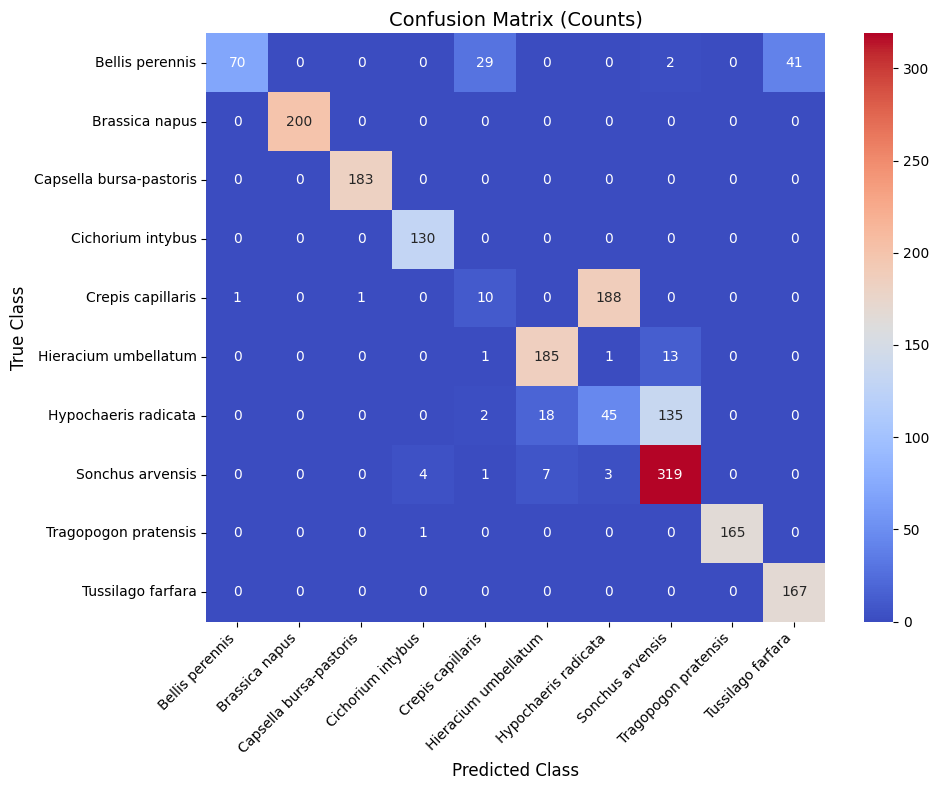

In [8]:
BATCHSIZE = 32

ckpt = torch.load("models/saved_models/convnext_tiny_size_aug_sepval.pth", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.to(device)

test_loader  = DataLoader(test_dataset, batch_size=BATCHSIZE, shuffle=True, num_workers=0)
recall_per_class, accuracy, val_loss, conf = eval_epoch(model, test_loader, device, recall_metric, accuracy_metric, confmat_metric=confmat_metric, loss_fn=None)
print(f"Test Accuracy: {accuracy:.4f}")
print("Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {r:.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)

In [13]:
pair = choose_specialist_pair(recall_per_class, conf)
print("Chosen specialist pair:", pair, idx_to_class[pair[0]], "vs", idx_to_class[pair[1]])

Chosen specialist pair: (4, 6) Crepis capillaris vs Hypochaeris radicata


In [14]:
# embed_dim depends on stage-1 backbone:
# ResNet18 backbone output = 512
# ConvNeXtTiny embedding = 768
embed_dim = 768  

specialist, best_val_acc, best_epoch = train_binary_specialist(
    stage1_model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    device=device,
    class_a=pair[0],
    class_b=pair[1]
    ,epochs=8,
    batch_size=32,
)

100%|██████████| 44/44 [00:04<00:00,  9.53it/s]


Epoch 1/8 | Train Loss: 0.0914, Train Acc: 0.9609 | Val Loss: 0.0035, Val Acc: 1.0000
Val Recall per class: tensor([1., 1.])
New best specialist (Val Acc=1.0000) at epoch 1


100%|██████████| 44/44 [00:04<00:00,  9.52it/s]


Epoch 2/8 | Train Loss: 0.0046, Train Acc: 0.9986 | Val Loss: 0.0036, Val Acc: 1.0000


100%|██████████| 44/44 [00:04<00:00,  9.65it/s]


...

Epoch 4/8 | Train Loss: 0.0016, Train Acc: 1.0000 | Val Loss: 0.0036, Val Acc: 1.0000


100%|██████████| 44/44 [00:04<00:00,  9.65it/s]


Epoch 5/8 | Train Loss: 0.0036, Train Acc: 0.9986 | Val Loss: 0.0032, Val Acc: 1.0000
Val Recall per class: tensor([1., 1.])


100%|██████████| 44/44 [00:04<00:00,  9.38it/s]


Epoch 6/8 | Train Loss: 0.0011, Train Acc: 1.0000 | Val Loss: 0.0026, Val Acc: 1.0000
Early stopping at epoch 6. Best Val Acc=1.0000 (epoch 1).
Reloaded best specialist from epoch 1 (Val Acc=1.0000)


Two-stage Test Accuracy: 0.7661
Two-stage Test Recall per class:
Class 0 (Bellis perennis): 0.4930
Class 1 (Brassica napus): 1.0000
Class 2 (Capsella bursa-pastoris): 1.0000
Class 3 (Cichorium intybus): 1.0000
Class 4 (Crepis capillaris): 0.0400
Class 5 (Hieracium umbellatum): 0.9250
Class 6 (Hypochaeris radicata): 0.2200
Class 7 (Sonchus arvensis): 0.9551
Class 8 (Tragopogon pratensis): 0.9940
Class 9 (Tussilago farfara): 1.0000


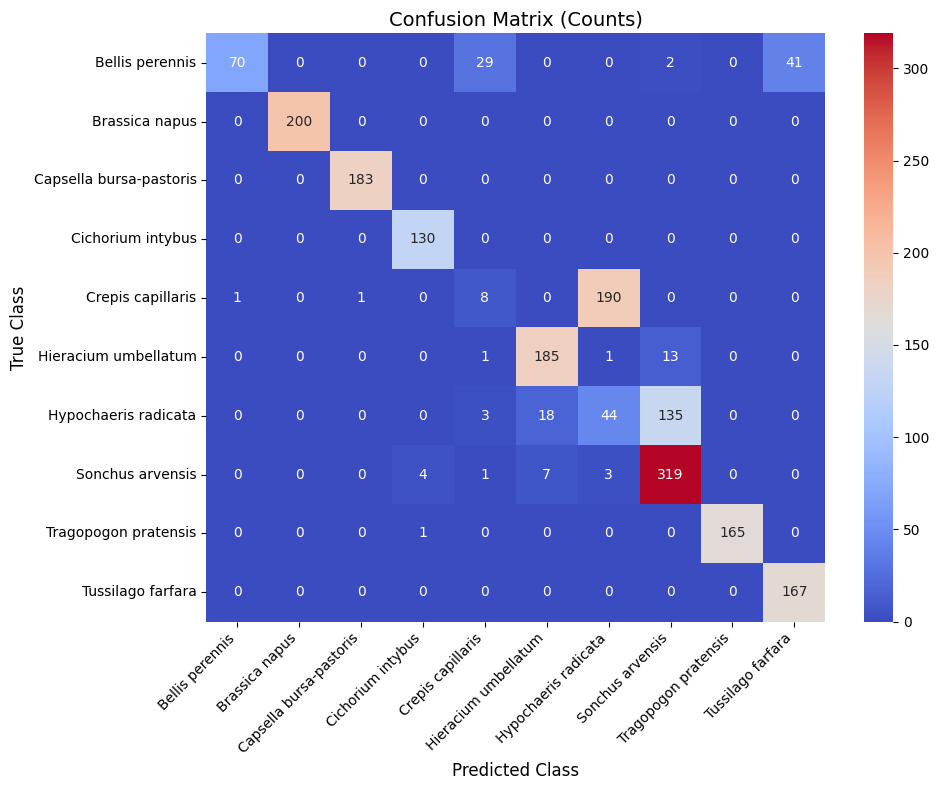

In [15]:
all_preds = []
all_true = []

for imgs, sizes, y in test_loader:
    imgs, sizes = imgs.to(device), sizes.to(device)
    p = two_stage_predict(model, specialist, pair, imgs, sizes, device, gate="")
    all_preds.append(p.cpu())
    all_true.append(y.cpu())

all_preds = torch.cat(all_preds)
all_true = torch.cat(all_true)

recall_metric = recall_metric.cpu()
recall_metric.reset()
recall_metric.update(all_preds, all_true)
recall_per_class = recall_metric.compute().cpu()

accuracy_metric = accuracy_metric.cpu()
accuracy_metric.update(all_preds, all_true)
accuracy = accuracy_metric.compute().item()

confmat_metric = confmat_metric.cpu()
confmat_metric.reset()
confmat_metric.update(all_preds, all_true)
conf = confmat_metric.compute()

print(f"Two-stage Test Accuracy: {accuracy:.4f}")
print("Two-stage Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {float(r):.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)



In [ ]:
all_preds = []
all_true = []

for imgs, sizes, y in test_loader:
    imgs, sizes = imgs.to(device), sizes.to(device)
    p = two_stage_predict(model, specialist, pair, imgs, sizes, device, gate="hard")
    all_preds.append(p.cpu())
    all_true.append(y.cpu())

all_preds = torch.cat(all_preds)
all_true = torch.cat(all_true)

recall_metric = recall_metric.cpu()
recall_metric.reset()
recall_metric.update(all_preds, all_true)
recall_per_class = recall_metric.compute().cpu()

accuracy_metric = accuracy_metric.cpu()
accuracy_metric.update(all_preds, all_true)
accuracy = accuracy_metric.compute().item()

confmat_metric = confmat_metric.cpu()
confmat_metric.reset()
confmat_metric.update(all_preds, all_true)
conf = confmat_metric.compute()

print(f"Two-stage Test Accuracy: {accuracy:.4f}")
print("Two-stage Test Recall per class:")
for i, r in enumerate(recall_per_class):
    print(f"Class {i} ({idx_to_class[i]}): {float(r):.4f}")

plot_confusion_matrix(conf, idx_to_class, normalize=False)



In [10]:
import os
import pandas as pd
from torch.utils.data import Subset

def unwrap_subset(ds):
    """
    Returns (base_dataset, absolute_indices) where absolute_indices index into base_dataset.
    Works even if ds is Subset(Subset(...)).
    """
    if not isinstance(ds, Subset):
        return ds, None

    indices = list(ds.indices)
    base = ds.dataset

    while isinstance(base, Subset):
        # map indices through the next subset level
        indices = [base.indices[i] for i in indices]
        base = base.dataset

    return base, indices

def get_flower_ids(ds_or_subset):
    base, abs_indices = unwrap_subset(ds_or_subset)

    # Get filenames
    if abs_indices is None:
        # not a subset
        filenames = [os.path.basename(p) for (p, _) in base.samples]
    else:
        filenames = [os.path.basename(base.samples[i][0]) for i in abs_indices]

    df = pd.DataFrame({"filename": filenames})
    df["flower_id"] = (
        df["filename"]
        .str.split(" ").str[-1]
        .str.split("_").str[0]
    )
    return set(df["flower_id"])

In [12]:
train_ids = get_flower_ids(train_dataset)
val_ids   = get_flower_ids(val_dataset)

overlap = train_ids.intersection(val_ids)
print("Flower_id overlap:", len(overlap))
assert len(overlap) == 0

IndexError: list index out of range